# ACCESS AM3 Scaling Results Notebook

In [1]:
%load_ext autoreload
%autoreload 2

## Package versions

In [2]:
import importlib.metadata
for pkg in ("access.profiling",):
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

access.profiling: 0.2.dev2+g6cf15c30c


## Experiment Setup

This notebook performs scaling studies on the n96e 3.0 AM3 configuration. The setup steps are similar to that in the "[Run ACCESS-rAM](https://docs.access-hive.org.au/models/run-a-model/run-access-ram/)" instructions with some differences:

* Instead of cloning a UK Met Office SVN repository, the `release-n96e-3.0` tag from `https://github.com/ACCESS-NRI/access-ram-configs.git` is used instead.
* Single 1h chunk of in-simulation time is used (rather than 12h that comes by default).

At the time of writing, the `access-ram-configs` repository is private and may need github authentication if executing this notebook.

Exact commands to setup on NCI's Gadi HPC:

```bash
session_name=am3-scaling
project=${PROJECT} # change to your preferred project

# start a persistent session
persistent-sessions start -p ${project} $session_name

# assign persistent session to Rose/Cylc
echo "${session_name}.${USER}.${project}.ps.gadi.nci.org.au" > ~/.persistent-sessions/cylc-session

# rose/cylc setup
module use /g/data/hr22/modulefiles
module load cylc7
```

Run the below code blocks to clone the repository, checkout the configuration, and setup the run directories for the scaling study.

In [3]:
!mkdir -p ~/roses
!git clone git@github.com:ACCESS-NRI/ACCESS-AM3-configs.git -b release-n96e-3.0 ~/roses/am3-release-n96e-3.0

fatal: destination path '/home/555/ey7514/roses/am3-release-n96e-3.0' already exists and is not an empty directory.


The below cell creates new experiment directories *only if* no archived result was found for that experiment - registering the experiment in the process as well.

In [ ]:
## Setup experiments (to be replaced by experiment generator)
from access.config.layout_config import find_layouts_with_maxncore
from access.profiling import RAM3Profiling
from access.profiling.experiment import ProfilingExperiment
from pathlib import Path
from shutil import copytree

cpus_per_node = 48 # normal
# sapphirerapids = 104

base_exp = Path.home() / "roses/am3-release-n96e-3.0"
target_dir = base_exp.parent

work_dir = Path.home() / "roses"
cylc_run_prefix = Path("/scratch/tm70/ey7514/cylc-run/am3-release-n96e-3.0")
archive_dir = Path("/g/data/tm70/model_scaling/ACCESS-AM3/release-n96e-3.0")  # only used if archive_experiments() is called later

profiling = RAM3Profiling(
    work_dir=work_dir,
    archive_dir=archive_dir,
    layout_variable=("MAIN_ATM_PROCY", "MAIN_ATM_PROCX"),
    cpus_per_proc_variable="MAIN_OMPTHR_ATM",  # OpenMP threads per MPI process
    io_server_variable="MAIN_IOS_NPROC",  # dedicated IO server ranks, not part of the atmos layout
)

# dict[str, tuple] of files with lines to replace
files_to_edit = {
    "rose-suite.conf": [
        # update core layout
        ("MAIN_ATM_PROCY=24", "MAIN_ATM_PROCY={layout_y}"),
        ("MAIN_ATM_PROCX=24", "MAIN_ATM_PROCX={layout_x}"),
        ("EXPT_RUNLEN='P12M'", "EXPT_RUNLEN='P1M'"),
        ("MAIN_CLOCK='PT1H10M'", "MAIN_CLOCK='PT24H00M'"),
        ("NETCDF_PP=true", "NETCDF_PP=false"),
    ],
    # ensure there's enough memory for 24-core case
    "site/nci_gadi.rc": [
        ("{% macro pbs_mem(x,y,i=0,nt=1,per_cpu=2) -%}", "{% macro pbs_mem(x,y,i=0,nt=1,per_cpu=4) -%}")
    ],
    "app/um/rose-app.conf": [
        # print timers for parsing
        ("ltimer=.false.", "ltimer=.true."),
    ],
}

def replace_line_in_file(file, old_txt, new_txt):
    """Crude substitute for experiment generator's text replacement."""
    with open(file, 'r') as f:
        lines = f.readlines()
    lines = [line.replace(old_txt, new_txt) for line in lines]
    with open(file, 'w') as f:
        f.writelines(lines)

def copy_base_and_edit_files(base_exp: Path, new_exp: Path, total_cpus: int, files_to_edit: dict):
    """Helper function to copy the base experiment and edit config files."""
    copytree(base_exp, new_exp, dirs_exist_ok=True)

    # estimate a new layout
    best_layout = find_layouts_with_maxncore(
        total_cpus, 
        even_nx=True, 
        prefer_nx_greater_than_ny=True
    )
    # choose the layout that minimizes waste
    best_layout = sorted(best_layout, key=lambda x: x[0]*x[1]%48)[0]
    best_layout = int(best_layout[0]), int(best_layout[1]) # handle floats

    print(f"{num_nodes} nodes - layout: {best_layout}")

    # perform line replacement
    for file, lines_to_replace in files_to_edit.items():
        for line in lines_to_replace:
            replace_line_in_file(new_exp / file, line[0], line[1].format(layout_x=best_layout[0], layout_y=best_layout[1]))

for num_nodes in (0.5, 1, 2, 3, 6, 12, 24):

    total_cpus = int(num_nodes*cpus_per_node)

    new_exp_name = f"am3-release-n96e-3.0-{total_cpus}"
    print(f"Creating new experiment: {new_exp_name}")
    if new_exp_name not in profiling.experiments:
        new_exp = target_dir / new_exp_name

        copy_base_and_edit_files(base_exp, new_exp, total_cpus, files_to_edit)

        profiling.experiments[new_exp_name] = ProfilingExperiment(
            path=work_dir / new_exp_name,
            run_path=Path(f"{cylc_run_prefix}-{total_cpus}"),
        )
        print(f"    Created new experiment at {new_exp}")
    else:
        print("    Found archived result - skipping.")

The cell below starts the non-archived registered experiments via `run_experiments()`, which calls `rose suite-run` for each.

**Note:** `run_experiments()` only submits the suites — it does not wait for Cylc to actually finish running
them. Check that the suites have completed (e.g. via `cylc scan`, `rose suite-log`, or the ARE GUI) before
running the "Parse rAM3 profiling data" cell further down.

Alternatively, you can still run them manually/interactively via an X11 ssh (`ssh -YC4`) session or an ARE
session:

```bash
for rundir in ~/roses/am3-release-n96e-3.0-*
do
    cd "$rundir" && rose suite-clean -y && rose suite-run
done
```

In [5]:
## Run AM3 profiling experiments
# Submits each suite via `rose suite-run`. Does not block until Cylc actually finishes running them.
profiling.run_experiments()

Run the below cell once all the cylc runs have been confirmed to be completed. The logs from completed runs and archived results will automatically be parsed.

In [6]:
profiling.parse_profiling_data()

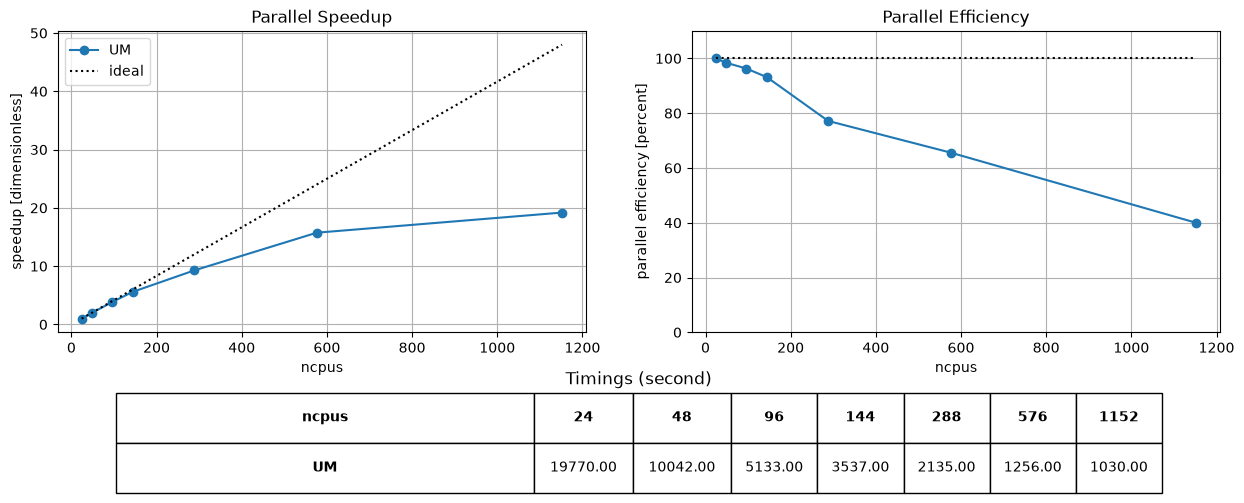

In [7]:
from access.profiling.metrics import tmax
scaling_plot = profiling.plot_scaling_data(
    components=["cylc_tasks"],
    regions=[
        ["atmos_main_cycle19820101T0000Z",]
    ], 
    metric=tmax,
    region_relabel_map={
        "atmos_main_cycle19820101T0000Z": "UM",
    }
)

Here, we've performed a strong scaling study on the ACCESS-AM3 n96e-3.0 configuration, which is based on the
UK Met Office's Unified Model (UM). The tests shown here use UM v13.8 using the `release-n96e-3.0` configuration
from the ACCESS-AM3-configs repository. This configuration is a single global atmosphere model at N96 resolution -
a 192 by 144 grid in longitude and latitude, with 85 vertical levels.

The execution of the atmosphere model is managed using Cylc Rose. The timings reported only reflect the time taken for the model to execute (`atmos_main`), and excludes any pre- and post-processing steps.

The configuration is currently setup to run on the NCI "normal" queue, which consists of Cascade Lake nodes which
each have 48 CPU cores. The scaling tests here are run between half a node (24 cores) up to 24 nodes (1152 cores).
The tests are run for 1 month of in-simulation time (reduced from the 12-month default) to keep the scaling study tractable.

The UM has additional OpenMP threading capabilities, but that isn't used here. Similarly, the UM IO server capability is not leveraged in this configuration. Despite this, IO takes, at most, 5% of the total runtime in these tests.

In the figure, `ncpus` represents the total number of CPU cores used to run the model. When compared to the base value of 24 CPU cores, we achieve a speedup of approximately 19x at 1152
cores (24 Cascade Lake nodes) - representing an efficiency of approximately 40%. Efficiency degrades steadily
with core count, from around 98% at 48 cores down to 40% at 1152 cores. At N96 resolution the global grid is only 192 by 144
points, so at 1152 cores each processor owns only around 24 grid columns. This results in communication due to halo exchanges increasingly dominating as a proportion of total runtime.

In [8]:
# archive the results for later
profiling.archive_experiments()

Experiment at /g/data/tm70/model_scaling/ACCESS-AM3/release-n96e-3.0/am3-release-n96e-3.0-576.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-AM3/release-n96e-3.0/am3-release-n96e-3.0-288.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-AM3/release-n96e-3.0/am3-release-n96e-3.0-1152.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-AM3/release-n96e-3.0/am3-release-n96e-3.0-48.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-AM3/release-n96e-3.0/am3-release-n96e-3.0-96.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-AM3/release-n96e-3.0/am3-release-n96e-3.0-24.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-AM3/release-n96e-3.0/am3-release-n96e-3.0-144.tar.gz is already archived. Skipping archiving.
